<a href="https://colab.research.google.com/github/Amarnath2908/Celebal-Excellence-Internship/blob/main/Week3_BAmarnath.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORT STATEMENTS

In [ ]:

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# DATASET LOAD

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'unsupervised-learning-on-country-data' dataset.
Path to dataset files: /kaggle/input/unsupervised-learning-on-country-data


In [ ]:
import os
print(os.listdir(path))

['Country-data.csv', 'data-dictionary.csv']


In [ ]:
import pandas as pd
df = pd.read_csv(path + "/Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# DATASET UNDERSTANDING

In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Records:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape:
(167, 10)

Columns:
['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

First 5 Records:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB

Statistical Summary:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


# MISSING VALUES

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


# DUPLICATE ROWS

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# VISUALIZATION

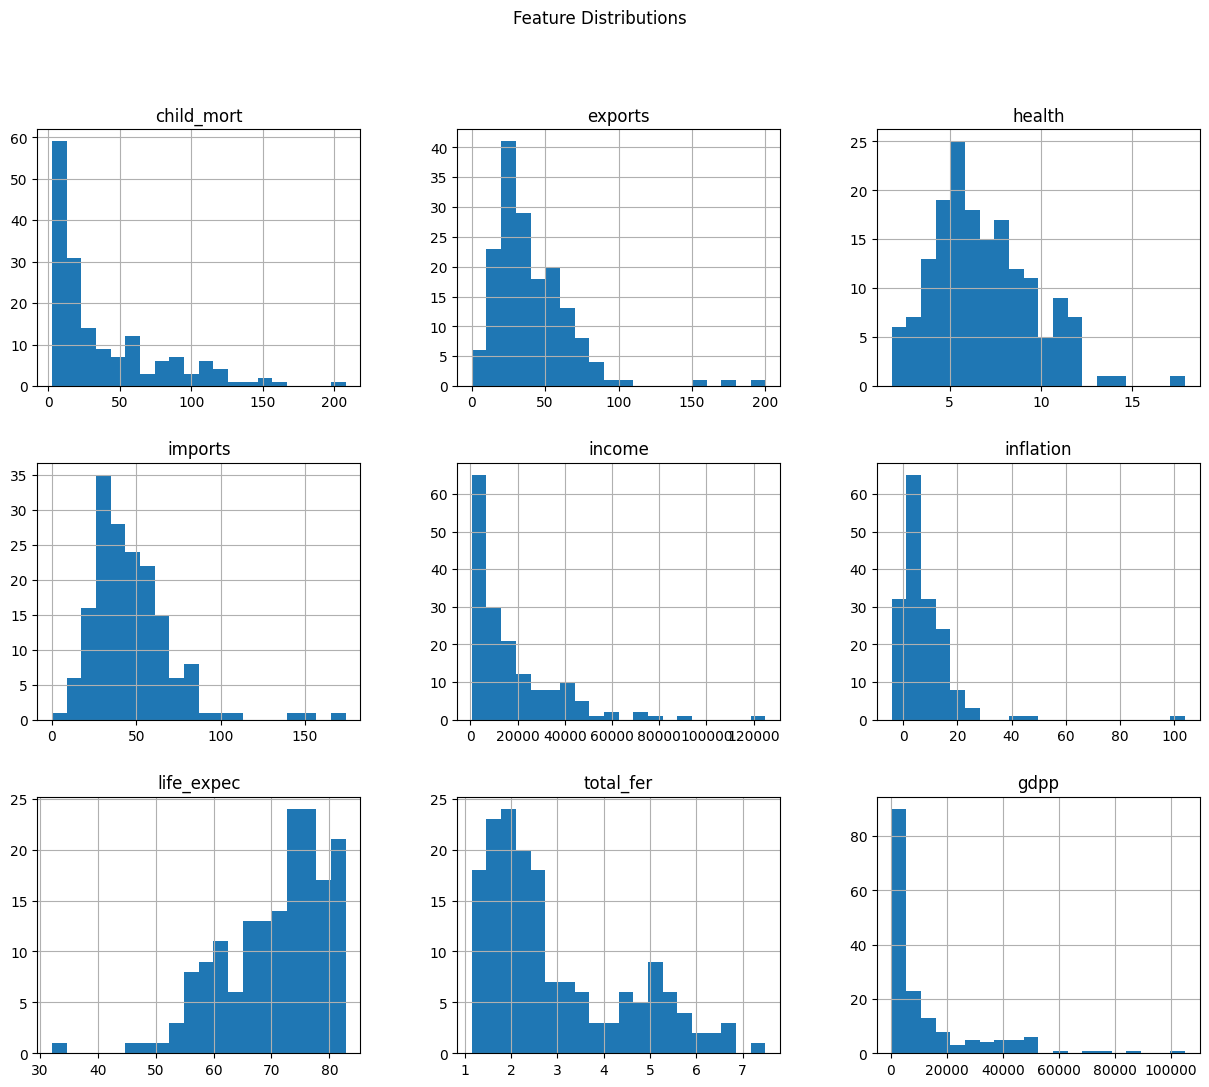

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(
    figsize=(15,12),
    bins=20
)

plt.suptitle("Feature Distributions")
plt.show()

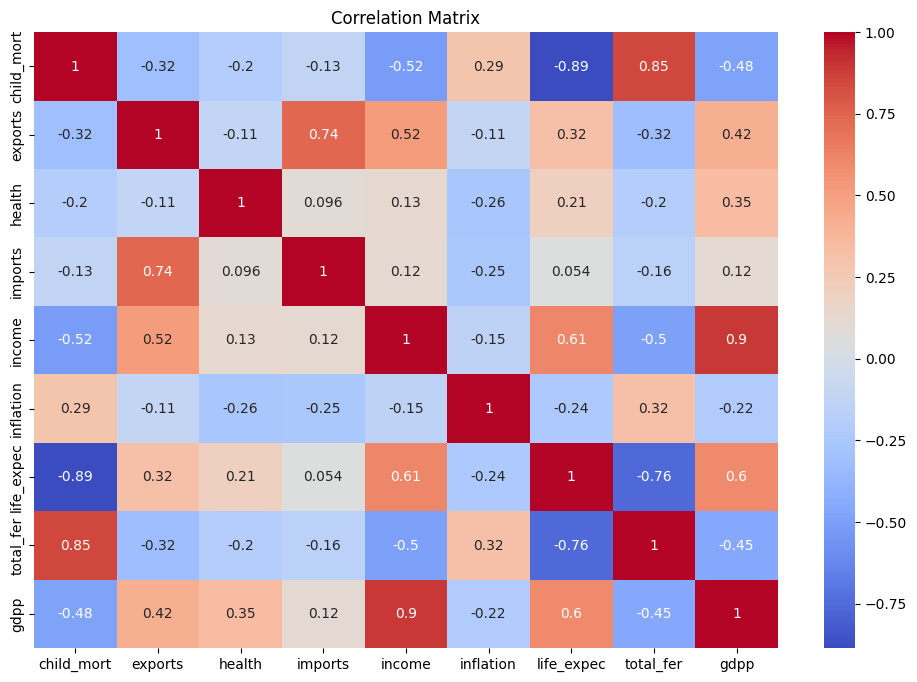

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.drop('country', axis=1).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

# DATA CLEANING

In [ ]:
# Remove extra spaces
df.columns = df.columns.str.strip()

# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert numeric columns
for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(
            df[col],
            errors='coerce'
        )

# Missing values before
print("Missing Values Before:")
print(df.isnull().sum())

# Median Imputation
numeric_cols = df.columns.drop('country')

imputer = SimpleImputer(strategy='median')

df[numeric_cols] = imputer.fit_transform(
    df[numeric_cols]
)

print("\nMissing Values After:")
print(df.isnull().sum())

Missing Values Before:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Missing Values After:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


# FEATURE ENGINEERING

In [ ]:
country_names = df['country']

X = df.drop(
    'country',
    axis=1
)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Shape:", X_scaled.shape)

Scaled Shape: (167, 9)


# ELBOW METHOD

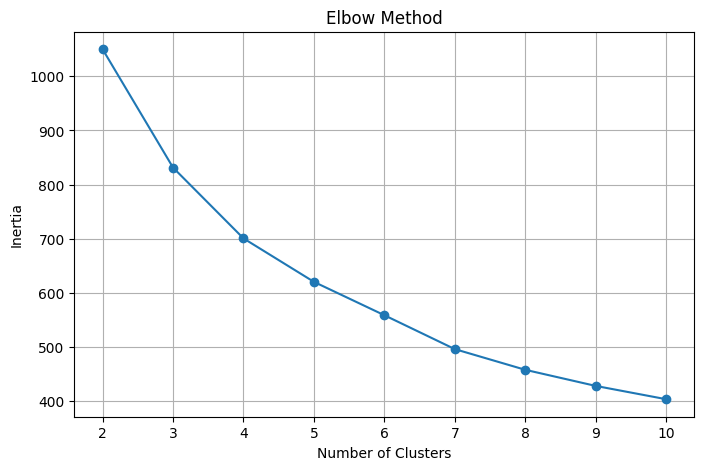

In [ ]:
inertia_values = []

k_values = range(2,11)

for k in k_values:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_scaled)

    inertia_values.append(
        km.inertia_
    )

plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    inertia_values,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid(True)
plt.show()

# MODEL TRAINING

In [ ]:
best_k = 3

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(
    X_scaled
)

df["KMeans_Cluster"] = kmeans_labels

print(df[
    ['country','KMeans_Cluster']
].head())

               country  KMeans_Cluster
0          Afghanistan               1
1              Albania               2
2              Algeria               2
3               Angola               1
4  Antigua and Barbuda               2


In [ ]:
sil_score = silhouette_score(
    X_scaled,
    kmeans_labels
)

print(
    f"Silhouette Score: {sil_score:.4f}"
)

Silhouette Score: 0.2833


In [ ]:
if sil_score > 0.7:
    print("Excellent cluster separation")
elif sil_score > 0.5:
    print("Good cluster separation")
elif sil_score > 0.3:
    print("Moderate cluster separation")
else:
    print("Weak cluster separation")

Weak cluster separation


# DBSCAN CLUSTERING

In [ ]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(
    X_scaled
)

df["DBSCAN_Cluster"] = dbscan_labels

print("DBSCAN Cluster Counts:")

print(
    pd.Series(
        dbscan_labels
    ).value_counts().sort_index()
)

DBSCAN Cluster Counts:
-1     30
 0    137
Name: count, dtype: int64


# COMPARISON

In [ ]:
comparison = pd.DataFrame({
    "Country": country_names,
    "KMeans": kmeans_labels,
    "DBSCAN": dbscan_labels
})

display(comparison.head(10))

,Country,KMeans,DBSCAN
0,Afghanistan,1,0
1,Albania,2,0
2,Algeria,2,0
3,Angola,1,-1
4,Antigua and Barbuda,2,0
5,Argentina,2,0
6,Armenia,2,0
7,Australia,0,0
8,Austria,0,0
9,Azerbaijan,2,0


# PCA VISUALIZATION

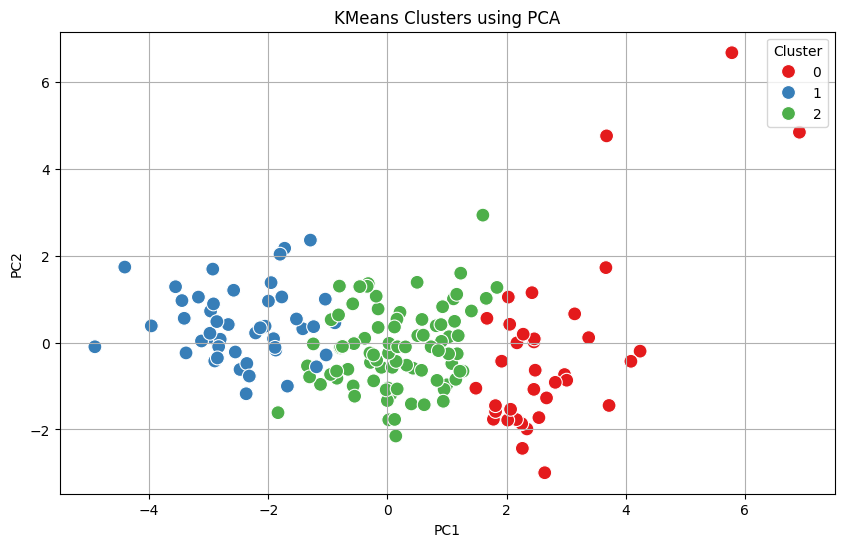

In [ ]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "Cluster": kmeans_labels
})

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=100
)

plt.title(
    "KMeans Clusters using PCA"
)

plt.grid(True)
plt.show()

In [ ]:
cluster_profile = df.groupby(
    "KMeans_Cluster"
).mean(numeric_only=True)

display(cluster_profile)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,-0.250000
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979,-0.340426
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381,-0.059524


# TOP CLUSTERS

In [ ]:
for cluster in sorted(df["KMeans_Cluster"].unique()):

    print("\n")
    print("="*50)
    print(f"Cluster {cluster}")
    print("="*50)

    display(
        df[df["KMeans_Cluster"]==cluster]
        [["country"]]
        .head(10)
    )



Cluster 0


,country
7,Australia
8,Austria
11,Bahrain
15,Belgium
23,Brunei
29,Canada
42,Cyprus
43,Czech Republic
44,Denmark
53,Finland




Cluster 1


,country
0,Afghanistan
3,Angola
17,Benin
21,Botswana
25,Burkina Faso
26,Burundi
28,Cameroon
31,Central African Republic
32,Chad
36,Comoros




Cluster 2


,country
1,Albania
2,Algeria
4,Antigua and Barbuda
5,Argentina
6,Armenia
9,Azerbaijan
10,Bahamas
12,Bangladesh
13,Barbados
14,Belarus


# OBSERVATIONS

In [21]:
print("="*60)
print("SECTION 14: OBSERVATIONS")
print("="*60)

print("\nObservation 1: High Mortality Cluster")
print("- Countries in this cluster have high child mortality.")
print("- Life expectancy is lower compared to other clusters.")
print("- Healthcare spending is generally low.")
print("- These countries are less developed and need better healthcare support.")

print("\nObservation 2: Strong Economic Cluster")
print("- Countries in this cluster have high GDP and income.")
print("- People live longer and mortality rates are low.")
print("- Healthcare spending is higher.")
print("- These countries are generally developed nations.")

print("\nObservation 3: Developing Countries Cluster")
print("- Countries in this cluster have moderate GDP and income.")
print("- Healthcare and living standards are improving.")
print("- Mortality rates are neither very high nor very low.")
print("- These countries are in the process of economic growth.")

print("\nObservation 4: PCA Visualization")
print("- The PCA plot shows clear separation between clusters.")
print("- This indicates that country features are useful for grouping countries.")
print("- Countries with similar development levels are placed together.")

print("\nObservation 5: K-Means vs DBSCAN")
print("- K-Means grouped all countries into 3 clusters.")
print("- DBSCAN identified some countries as outliers (-1 label).")
print("- K-Means provided more meaningful groups for this dataset.")
print("- Therefore, K-Means is the better clustering method here.")

print("\nConclusion")
print("- Countries were successfully divided into Developed, Developing, and Underdeveloped groups.")
print("- Economic and health indicators played an important role in forming these clusters.")
print("- The clustering results can help understand global development patterns.")

SECTION 14: OBSERVATIONS

Observation 1: High Mortality Cluster
- Countries in this cluster have high child mortality.
- Life expectancy is lower compared to other clusters.
- Healthcare spending is generally low.
- These countries are less developed and need better healthcare support.

Observation 2: Strong Economic Cluster
- Countries in this cluster have high GDP and income.
- People live longer and mortality rates are low.
- Healthcare spending is higher.
- These countries are generally developed nations.

Observation 3: Developing Countries Cluster
- Countries in this cluster have moderate GDP and income.
- Healthcare and living standards are improving.
- Mortality rates are neither very high nor very low.
- These countries are in the process of economic growth.

Observation 4: PCA Visualization
- The PCA plot shows clear separation between clusters.
- This indicates that country features are useful for grouping countries.
- Countries with similar development levels are placed tog